In [1]:
# Load the libraries we'll use for data work and plotting.
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np

In [2]:
# Widen pandas' display so we can see more rows and full column text.
pd.set_option('display.max_rows', 1000)
pd.set_option("display.max_colwidth", 10)

In [ ]:
# Load the three raw data files: orders, orderlines, and products.
orders_df = pd.read_csv('orders.clean.csv').copy()
orderlines_df = pd.read_csv('orderlines.clean.csv').copy()
products_df = pd.read_csv('products.clean.csv').copy()

In [4]:
# Attach each orderline's catalog price by matching on SKU.
disc = orderlines_df.merge(products_df[['sku', 'price']], how='left', on='sku')

In [5]:
# Work out how much discount (in euros) was given on each line.
disc['discount'] = disc['price'] - disc['unit_price']


In [6]:
# Turn that euro discount into a percentage of the catalog price.
disc['discount_pct'] = disc['discount'] / disc['price'] * 100
disc

,id,id_order,product_id,product_quantity,sku,unit_price,date,price,discount,discount_pct
0,1119116,299545,0,1,OWC0100,47.49,2017-0...,60.99,13.50,22.134776
1,1119119,299546,0,1,IOT0014,18.99,2017-0...,22.95,3.96,17.254902
2,1119120,295347,0,1,APP0700,72.19,2017-0...,89.00,16.81,18.887640
3,1119134,299556,0,1,CRU0039-A,60.90,2017-0...,76.99,16.09,20.898818
4,1119145,299561,0,1,PEB0015,142.49,2017-0...,299.99,157.50,52.501750
...,...,...,...,...,...,...,...,...,...,...
53226,1649447,527035,0,1,APP0698,9.99,2018-0...,25.00,15.01,60.040000
53227,1649512,527070,0,2,APP0698,9.99,2018-0...,25.00,15.01,60.040000
53228,1649522,527074,0,2,APP0698,9.99,2018-0...,25.00,15.01,60.040000
53229,1649565,527096,0,3,APP0698,9.99,2018-0...,25.00,15.01,60.040000


In [7]:
# Calculate the revenue each line actually brought in.
disc['revenue'] = disc['unit_price'] * disc['product_quantity']


In [8]:
# Discount and revenue Price category wise

In [9]:
# Check the data types of each column.
disc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53231 entries, 0 to 53230
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                53231 non-null  int64  
 1   id_order          53231 non-null  int64  
 2   product_id        53231 non-null  int64  
 3   product_quantity  53231 non-null  int64  
 4   sku               53231 non-null  object 
 5   unit_price        53231 non-null  float64
 6   date              53231 non-null  object 
 7   price             53231 non-null  float64
 8   discount          53231 non-null  float64
 9   discount_pct      53231 non-null  float64
 10  revenue           53231 non-null  float64
dtypes: float64(5), int64(4), object(2)
memory usage: 4.5+ MB


In [10]:
# Convert the date column from text into a real date.
disc.date = pd.to_datetime(disc.date)

In [11]:
# Confirm the date column is now a proper datetime.
disc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53231 entries, 0 to 53230
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id                53231 non-null  int64         
 1   id_order          53231 non-null  int64         
 2   product_id        53231 non-null  int64         
 3   product_quantity  53231 non-null  int64         
 4   sku               53231 non-null  object        
 5   unit_price        53231 non-null  float64       
 6   date              53231 non-null  datetime64[ns]
 7   price             53231 non-null  float64       
 8   discount          53231 non-null  float64       
 9   discount_pct      53231 non-null  float64       
 10  revenue           53231 non-null  float64       
dtypes: datetime64[ns](1), float64(5), int64(4), object(1)
memory usage: 4.5+ MB


In [12]:
# Set the price cutoffs that split products into Budget, Mid, and High-end.
price_bins = [0, 50, 300, float('inf')]
price_bins

[0, 50, 300, inf]

In [13]:
# Name those three price groups.
price_labels = ['Budget\n(< €50)', 'Mid\n(€50-€300)', 'High-end\n(€300+)']
price_labels


['Budget\n(< €50)', 'Mid\n(€50-€300)', 'High-end\n(€300+)']

In [14]:
# Tag every product with its price tier.
products_df['price_tier'] = pd.cut(products_df['price'], bins=price_bins, labels=price_labels)
products_df


,sku,name,desc,price,in_stock,type,price_tier
0,RAI0007,Silver...,Alumin...,59.99,1,8696,Mid\n(...
1,APP0023,Apple ...,USB ul...,59.00,0,13855401,Mid\n(...
2,APP0025,Mighty...,mouse ...,59.00,0,1387,Mid\n(...
3,APP0072,Apple ...,IPhone...,25.00,0,1230,Budget...
4,KIN0007,Mac Me...,2GB RA...,34.99,1,1364,Budget...
...,...,...,...,...,...,...,...
9987,BEL0376,Belkin...,compac...,29.99,1,12282,Budget...
9988,THU0060,Enrout...,Backpa...,69.95,1,1392,Mid\n(...
9989,THU0061,Enrout...,Backpa...,69.95,1,1392,Mid\n(...
9990,THU0062,Enrout...,Backpa...,69.95,0,1392,Mid\n(...


In [15]:
# For each product, get its average discount and total revenue, then attach its price tier.
by_sku_price_cat = disc.groupby('sku').agg(
    avg_discount_pct=('discount_pct', 'mean'),
    revenue=('revenue', 'sum'),
).reset_index().merge(products_df[['sku', 'price_tier']], on='sku', how='left')

In [16]:
# Take a quick look at the result.
by_sku_price_cat

,sku,avg_discount_pct,revenue,price_tier
0,8MO0001-A,62.971429,12.96,Budget...
1,8MO0003-A,63.285714,12.85,Budget...
2,8MO0007,36.355102,155.93,Budget...
3,8MO0008,38.314286,235.89,Budget...
4,8MO0009,50.074286,87.37,Budget...
...,...,...,...,...
5093,ZAG0040,32.508127,26.99,Budget...
5094,ZAG0041,33.344448,19.99,Budget...
5095,ZAG0042,33.344448,19.99,Budget...
5096,ZEP0007,16.001067,125.99,Mid\n(...


In [17]:
# Find the average discount given within each price tier.
avg_discount = by_sku_price_cat.groupby('price_tier', observed=True)['avg_discount_pct'].mean()
avg_discount


price_tier
Budget\n(< €50)      24.397059
Mid\n(€50-€300)      20.300588
High-end\n(€300+)    16.465574
Name: avg_discount_pct, dtype: float64

In [18]:
# Find what share of total revenue each price tier brings in.
revenue_share = by_sku_price_cat.groupby('price_tier', observed=True)['revenue'].sum()
revenue_share = revenue_share / revenue_share.sum() * 100

revenue_share

price_tier
Budget\n(< €50)       5.869424
Mid\n(€50-€300)      38.001674
High-end\n(€300+)    56.128902
Name: revenue, dtype: float64

In [19]:
# Put both series in the same Budget -> Mid -> High-end order so they plot together.
avg_discount = avg_discount.reindex(price_labels)
revenue_share = revenue_share.reindex(price_labels)
avg_discount , revenue_share

(price_tier
 Budget\n(< €50)      24.397059
 Mid\n(€50-€300)      20.300588
 High-end\n(€300+)    16.465574
 Name: avg_discount_pct, dtype: float64,
 price_tier
 Budget\n(< €50)       5.869424
 Mid\n(€50-€300)      38.001674
 High-end\n(€300+)    56.128902
 Name: revenue, dtype: float64)

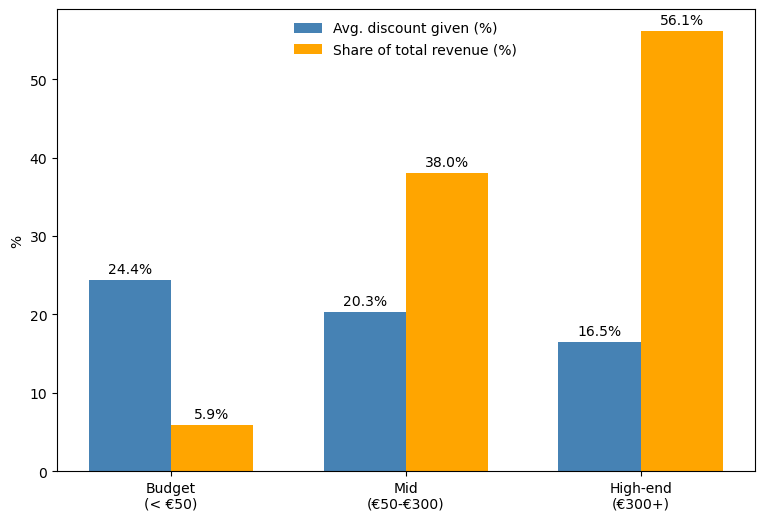

In [20]:
# Plot discount % next to revenue share for each price tier.
x = np.arange(len(price_labels))
width = 0.35

fig, ax = plt.subplots(figsize=(9, 6))
bars1 = ax.bar(x - width/2, avg_discount.values, width, color='steelblue', label='Avg. discount given (%)')
bars2 = ax.bar(x + width/2, revenue_share.values, width, color='orange', label='Share of total revenue (%)')

ax.bar_label(bars1, fmt='%.1f%%', padding=3)
ax.bar_label(bars2, fmt='%.1f%%', padding=3)

ax.set_xticks(x)
ax.set_xticklabels(price_labels)
ax.set_ylabel('%')
ax.legend(loc='upper center', frameon=False)



#

Next plot

In [21]:
# Roll the data up to one row per product: its average discount, total revenue, total units, and how many times it sold.
by_sku = disc.groupby('sku').agg(
    avg_dis_pct=('discount_pct', 'mean'), 
    total_revenue=('revenue', 'sum'), 
    total_units=('product_quantity', 'sum'),
    n_lines=('id_order', 'count') 
    ).reset_index()
    
by_sku 

,sku,avg_dis_pct,total_revenue,total_units,n_lines
0,8MO0001-A,62.971429,12.96,1,1
1,8MO0003-A,63.285714,12.85,1,1
2,8MO0007,36.355102,155.93,7,7
3,8MO0008,38.314286,235.89,11,10
4,8MO0009,50.074286,87.37,5,5
...,...,...,...,...,...
5093,ZAG0040,32.508127,26.99,1,1
5094,ZAG0041,33.344448,19.99,1,1
5095,ZAG0042,33.344448,19.99,1,1
5096,ZEP0007,16.001067,125.99,1,1


We only trust a product's numbers if it sold at least 5 times. If something sold just once or twice, that could easily be luck. not proof the discount worked. Selling 5+ times is more likely a real pattern.

In [22]:
# Keep only products that sold at least 5 times, so the averages are reliable.
by_sku_5 = by_sku[by_sku['n_lines'] >= 5]
by_sku_5

,sku,avg_dis_pct,total_revenue,total_units,n_lines
2,8MO0007,36.355102,155.93,7,7
3,8MO0008,38.314286,235.89,11,10
4,8MO0009,50.074286,87.37,5,5
6,8MO0011,41.457143,183.91,9,8
9,ADN0019,0.455114,103.47,13,11
...,...,...,...,...,...
5087,ZAG0032,63.334395,7515.63,207,196
5088,ZAG0034,66.688896,524.48,52,44
5089,ZAG0035,60.233808,397.65,25,24
5090,ZAG0036,54.174437,1157.16,84,81


In [23]:
# Sort each product into a discount bucket: no discount, 0-10%, 10-20%, 20-30%, or 30%+.
by_sku_5['tier'] = 'No discount'
by_sku_5.loc[(by_sku_5['avg_dis_pct'] > 0) & (by_sku_5['avg_dis_pct'] <= 10), 'tier'] = '0-10%'
by_sku_5.loc[(by_sku_5['avg_dis_pct'] > 10) & (by_sku_5['avg_dis_pct'] <= 20), 'tier'] = '10-20%'
by_sku_5.loc[(by_sku_5['avg_dis_pct'] > 20) & (by_sku_5['avg_dis_pct'] <= 30), 'tier'] = '20-30%'
by_sku_5.loc[by_sku_5['avg_dis_pct'] > 30, 'tier'] = '30%+'

/var/folders/_m/m0z6px9s0_b5y5jymcjxthb40000gn/T/ipykernel_4871/3115472310.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  by_sku_5['tier'] = 'No discount'


In [24]:
# Check the result.
by_sku_5

,sku,avg_dis_pct,total_revenue,total_units,n_lines,tier
2,8MO0007,36.355102,155.93,7,7,30%+
3,8MO0008,38.314286,235.89,11,10,30%+
4,8MO0009,50.074286,87.37,5,5,30%+
6,8MO0011,41.457143,183.91,9,8,30%+
9,ADN0019,0.455114,103.47,13,11,0-10%
...,...,...,...,...,...,...
5087,ZAG0032,63.334395,7515.63,207,196,30%+
5088,ZAG0034,66.688896,524.48,52,44,30%+
5089,ZAG0035,60.233808,397.65,25,24,30%+
5090,ZAG0036,54.174437,1157.16,84,81,30%+


In [25]:
# Set the order we want these buckets to appear in.
tier_order = ['No discount', '0-10%', '10-20%', '20-30%', '30%+']


In [26]:
# Find the average units sold and average revenue for each discount bucket.
tier_avg = by_sku_5.groupby('tier').agg(mean_units = ('total_units', 'mean'), mean_revenue = ('total_revenue', 'mean'))
tier_avg = tier_avg.reindex(tier_order)                  
tier_avg = tier_avg.reset_index() 
tier_avg

,tier,mean_units,mean_revenue
0,No dis...,13.470588,5070.2...
1,0-10%,23.920696,4531.3...
2,10-20%,26.826152,3853.6...
3,20-30%,25.521368,2723.9...
4,30%+,25.238876,793.59...


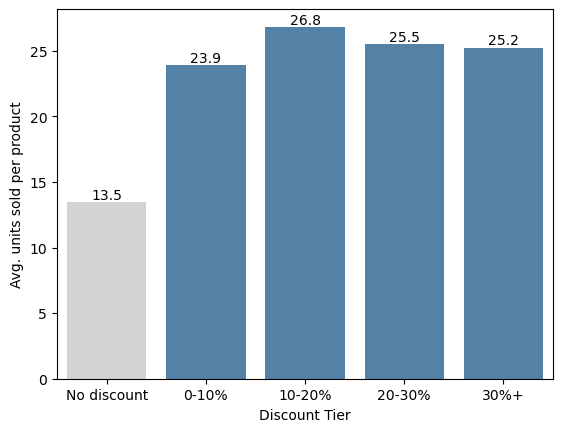

In [27]:
# Plot average units sold by discount bucket, with the no-discount bar in gray.
ax = sns.barplot(data=tier_avg, x='tier', y='mean_units', color='steelblue')
ax.set_ylabel('Avg. units sold per product')
ax.set_xlabel('Discount Tier')
ax.bar_label(ax.containers[0], fmt='%.1f')
ax.patches[0].set_facecolor('lightgray')

<Axes: xlabel='tier', ylabel='mean_revenue'>

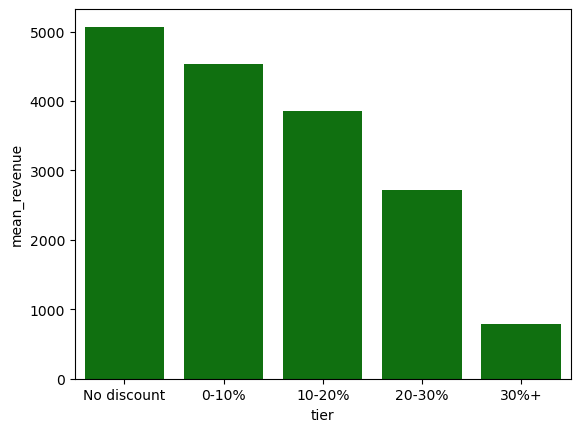

In [28]:
# Plot average revenue by discount bucket.
sns.barplot(data=tier_avg, x='tier', y='mean_revenue', color='green')


In [29]:
# Check the columns again before the next step.
disc.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 53231 entries, 0 to 53230
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id                53231 non-null  int64         
 1   id_order          53231 non-null  int64         
 2   product_id        53231 non-null  int64         
 3   product_quantity  53231 non-null  int64         
 4   sku               53231 non-null  object        
 5   unit_price        53231 non-null  float64       
 6   date              53231 non-null  datetime64[ns]
 7   price             53231 non-null  float64       
 8   discount          53231 non-null  float64       
 9   discount_pct      53231 non-null  float64       
 10  revenue           53231 non-null  float64       
dtypes: datetime64[ns](1), float64(5), int64(4), object(1)
memory usage: 4.5+ MB


In [30]:
# Collapse the data to one row per order, with total revenue and order date.
grp_by_orders = disc.groupby('id_order').agg(order_revenue=('revenue', 'sum'), order_date=('date', 'min')).reset_index()
grp_by_orders

,id_order,order_revenue,order_date
0,241423,129.16,2017-11...
1,242832,10.77,2017-12...
2,243330,77.99,2017-02...
3,245275,149.00,2017-06...
4,245595,105.98,2017-01...
...,...,...,...
40980,527042,13.99,2018-03...
40981,527070,19.98,2018-03...
40982,527074,19.98,2018-03...
40983,527096,29.97,2018-03...


In [31]:
# Pull out the month from each order's date.
grp_by_orders['month'] = grp_by_orders['order_date'].dt.to_period('M')
grp_by_orders


,id_order,order_revenue,order_date,month
0,241423,129.16,2017-11...,2017-11
1,242832,10.77,2017-12...,2017-12
2,243330,77.99,2017-02...,2017-02
3,245275,149.00,2017-06...,2017-06
4,245595,105.98,2017-01...,2017-01
...,...,...,...,...
40980,527042,13.99,2018-03...,2018-03
40981,527070,19.98,2018-03...,2018-03
40982,527074,19.98,2018-03...,2018-03
40983,527096,29.97,2018-03...,2018-03


In [32]:
# Count orders and find the average order value for each month.
monthly = grp_by_orders.groupby('month').agg(
    n_orders=('id_order', 'nunique'),
    avg_order_value=('order_revenue', 'mean'))
monthly 

,n_orders,avg_order_value
month,,
2017-01,4625,132.03...
2017-02,2018,161.62...
2017-03,168,153.21...
2017-04,1469,157.13...
2017-05,1655,201.66...
2017-06,1336,213.60...
2017-07,3070,195.74...
2017-08,2092,179.82...
2017-09,1898,207.50...


In [33]:
# Add that same month column to the full line-level data.
disc['month'] = disc['date'].dt.to_period('M')
disc

,id,id_order,product_id,product_quantity,sku,unit_price,date,price,discount,discount_pct,revenue,month
0,1119116,299545,0,1,OWC0100,47.49,2017-01...,60.99,13.50,22.134776,47.49,2017-01
1,1119119,299546,0,1,IOT0014,18.99,2017-01...,22.95,3.96,17.254902,18.99,2017-01
2,1119120,295347,0,1,APP0700,72.19,2017-01...,89.00,16.81,18.887640,72.19,2017-01
3,1119134,299556,0,1,CRU0039-A,60.90,2017-01...,76.99,16.09,20.898818,60.90,2017-01
4,1119145,299561,0,1,PEB0015,142.49,2017-01...,299.99,157.50,52.501750,142.49,2017-01
...,...,...,...,...,...,...,...,...,...,...,...,...
53226,1649447,527035,0,1,APP0698,9.99,2018-03...,25.00,15.01,60.040000,9.99,2018-03
53227,1649512,527070,0,2,APP0698,9.99,2018-03...,25.00,15.01,60.040000,19.98,2018-03
53228,1649522,527074,0,2,APP0698,9.99,2018-03...,25.00,15.01,60.040000,19.98,2018-03
53229,1649565,527096,0,3,APP0698,9.99,2018-03...,25.00,15.01,60.040000,29.97,2018-03


In [34]:
# Add the average discount for each month too.
monthly['avg_discount_pct'] = disc.groupby('month')['discount_pct'].mean()


In [35]:
# Turn the month index back into a normal column.
monthly.reset_index(inplace=True)
monthly

,month,n_orders,avg_order_value,avg_discount_pct
0,2017-01,4625,132.03...,24.805867
1,2017-02,2018,161.62...,19.610861
2,2017-03,168,153.21...,18.956547
3,2017-04,1469,157.13...,18.293918
4,2017-05,1655,201.66...,15.304875
5,2017-06,1336,213.60...,17.414147
6,2017-07,3070,195.74...,24.904983
7,2017-08,2092,179.82...,20.531019
8,2017-09,1898,207.50...,20.116457
9,2017-10,2761,197.95...,21.979018


In [36]:
# Make a readable month label like 'Jan 2017' for the chart.
monthly['month_label'] = monthly.month.dt.strftime('%b %Y')
monthly

,month,n_orders,avg_order_value,avg_discount_pct,month_label
0,2017-01,4625,132.03...,24.805867,Jan 2017
1,2017-02,2018,161.62...,19.610861,Feb 2017
2,2017-03,168,153.21...,18.956547,Mar 2017
3,2017-04,1469,157.13...,18.293918,Apr 2017
4,2017-05,1655,201.66...,15.304875,May 2017
5,2017-06,1336,213.60...,17.414147,Jun 2017
6,2017-07,3070,195.74...,24.904983,Jul 2017
7,2017-08,2092,179.82...,20.531019,Aug 2017
8,2017-09,1898,207.50...,20.116457,Sep 2017
9,2017-10,2761,197.95...,21.979018,Oct 2017


[None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None,
 None]

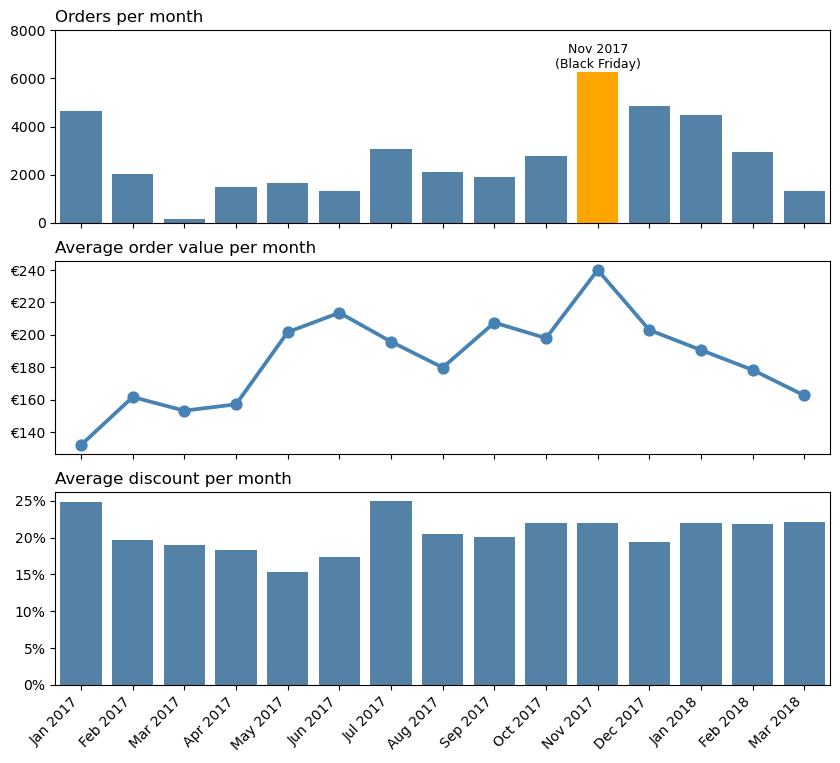

In [37]:
# Plot three things together: orders per month, average order value, and average discount -- with November 2017 (Black Friday) flagged.
fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(10, 8.5), sharex=True)
#first plot
sns.barplot(data=monthly, x='month_label', y='n_orders', color='steelblue', ax=ax1)
ax1.set_title('Orders per month',loc='left')
ax1.set_xlabel('')
ax1.set_ylabel('')
 
peak_i = monthly['n_orders'].idxmax()          
ax1.patches[peak_i].set_facecolor('orange')         
ax1.text(peak_i, monthly['n_orders'].max() + 150, 'Nov 2017\n(Black Friday)', ha='center', fontsize=9)
ax1.set_ylim(0, 8000)

#second plot
sns.pointplot(data=monthly, x='month_label', y='avg_order_value', color='steelblue'
, ax=ax2)
ax2.set_title('Average order value per month', loc='left')
ax2.set_xlabel('')
ax2.set_ylabel('')
ax2.yaxis.set_major_formatter(lambda v, pos: f'€{v:,.0f}')

#third plot
sns.barplot(data=monthly, x='month_label', y='avg_discount_pct', color='steelblue', ax=ax3)
ax3.set_title('Average discount per month', loc='left')
ax3.set_xlabel('')
ax3.set_ylabel('')
ax3.yaxis.set_major_formatter(lambda v, pos: f'{v:.0f}%')

 
plt.setp(ax3.get_xticklabels(), rotation=45, ha='right')